# Credit Scoring: predicting serious delinquency

**Goal:** estimate the probability that a borrower experiences a serious delinquency (90+ days past due)
within the next two years, from 10 financial and behavioural attributes.

This notebook walks through the full analysis:

1. Data: the original benchmark dataset and the larger Kaggle *Give Me Some Credit* dataset
2. Exploratory data analysis and data-quality issues
3. Cleaning and feature engineering
4. Experiment: does adding the Kaggle data improve the models?
5. Model selection, decision threshold and evaluation
6. Neural network (Keras) and TensorFlow Lite export

The reusable code lives in [`src/`](../src). The saved models are produced by `python -m src.train`.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))  # make `src` importable when running from notebooks/

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import classification_report, roc_auc_score

from src.data import RAW_FEATURES, TARGET, benchmark_ids, load_benchmark, load_gmsc
from src.features import build_features

sns.set_theme(style="whitegrid")
pd.set_option("display.float_format", "{:.3f}".format)

## 1. Data

| Column | Description |
|---|---|
| `rev_util` | Revolving utilisation: balance on credit cards / personal lines of credit divided by credit limits |
| `age` | Age of the borrower (years) |
| `late_30_59` | Number of times 30-59 days past due (not worse) in the last 2 years |
| `late_60_89` | Number of times 60-89 days past due (not worse) in the last 2 years |
| `late_90` | Number of times 90+ days late |
| `debt_ratio` | Monthly debt payments, alimony and living costs divided by monthly gross income |
| `monthly_inc` | Monthly income |
| `open_credit` | Number of open loans and lines of credit |
| `real_estate` | Number of mortgage and real estate loans |
| `dependents` | Number of dependents in the family |
| **`dlq_2yrs`** | **Target**: serious delinquency within 2 years (1 = default) |

In [2]:
bench = load_benchmark()
gmsc = load_gmsc()  # downloaded from Kaggle on first use
print(f"Benchmark dataset: {bench.shape}, default rate {bench[TARGET].mean():.1%}")
print(f"Give Me Some Credit: {gmsc.shape}, default rate {gmsc[TARGET].mean():.1%}")
bench.head()

Benchmark dataset: (16714, 11), default rate 50.0%
Give Me Some Credit: (150000, 11), default rate 6.7%


,rev_util,age,late_30_59,debt_ratio,monthly_inc,open_credit,late_90,real_estate,late_60_89,dependents,dlq_2yrs
0,0.007,38.000,0.000,0.302,5440.000,4.000,0.000,1.000,0.000,3.000,0
1,0.705,63.000,0.000,0.471,8000.000,9.000,0.000,1.000,0.000,0.000,0
2,0.063,57.000,0.000,0.069,5000.000,17.000,0.000,0.000,0.000,0.000,0
3,0.368,68.000,0.000,0.296,6250.000,16.000,0.000,2.000,0.000,0.000,0
4,1.000,34.000,1.000,0.000,3500.000,0.000,0.000,0.000,0.000,1.000,0


### Where does the benchmark dataset come from?

The benchmark has exactly the same columns as Kaggle's *Give Me Some Credit* competition data and a suspicious
50/50 class balance. Matching the rows confirms it is an **exact subsample**: all defaulters with complete data
plus the same number of randomly drawn non-defaulters.

In [3]:
ids = benchmark_ids(gmsc, bench)
complete = gmsc.dropna()
print(f"Benchmark rows found in GMSC: {len(ids):,} / {len(bench):,}")
print(f"Defaulters in benchmark:              {bench[TARGET].sum():,}")
print(f"Defaulters in GMSC with complete data: {complete[TARGET].sum():,}")
print(f"Defaulters in GMSC overall:            {gmsc[TARGET].sum():,}")

Benchmark rows found in GMSC: 16,712 / 16,714
Defaulters in benchmark:              8,357
Defaulters in GMSC with complete data: 8,357
Defaulters in GMSC overall:            10,026


So the Kaggle file adds about **133,000 rows**: ~1,700 extra defaulters (those with missing income or
dependents) and ~125,000 non-defaulters, with the **real-world default rate of 6.7%** instead of an artificial 50%.

## 2. Exploratory data analysis

In [4]:
missing = gmsc.isna().mean().mul(100).round(1)
missing[missing > 0].to_frame("% missing")

,% missing
monthly_inc,19.800
dependents,2.600


In [5]:
gmsc[RAW_FEATURES].describe(percentiles=[0.5, 0.99]).T

,count,mean,std,min,50%,99%,max
rev_util,150000.000,6.048,249.755,0.000,0.154,1.093,50708.000
age,150000.000,52.295,14.772,0.000,52.000,87.000,109.000
late_30_59,150000.000,0.421,4.193,0.000,0.000,4.000,98.000
debt_ratio,150000.000,353.005,2037.819,0.000,0.367,4979.040,329664.000
monthly_inc,120269.000,6670.221,14384.674,0.000,5400.000,25000.000,3008750.000
open_credit,150000.000,8.453,5.146,0.000,8.000,24.000,58.000
late_90,150000.000,0.266,4.169,0.000,0.000,3.000,98.000
real_estate,150000.000,1.018,1.130,0.000,1.000,4.000,54.000
late_60_89,150000.000,0.240,4.155,0.000,0.000,2.000,98.000
dependents,146076.000,0.757,1.115,0.000,0.000,4.000,20.000


Several data-quality issues stand out:

* **`late_*` = 96 or 98**: these are special codes in the source data, not real counts (nobody is late 98 times in 2 years).
* **`rev_util`** should be a ratio around 0-1 but reaches tens of thousands.
* **`debt_ratio`** explodes when income is missing: in that case it holds the debt amount rather than a ratio.
* **`age` = 0** appears once.

In [6]:
late_cols = ["late_30_59", "late_60_89", "late_90"]
print("Rows with a 96/98 code:", gmsc[late_cols].isin([96, 98]).any(axis=1).sum())
print("Default rate of those rows:", f"{gmsc.loc[gmsc[late_cols].isin([96, 98]).any(axis=1), TARGET].mean():.1%}")
print("Rows with rev_util > 10:", (gmsc.rev_util > 10).sum())
print("Median debt_ratio when income is missing:", gmsc.loc[gmsc.monthly_inc.isna(), "debt_ratio"].median())
print("Median debt_ratio when income is known:  ", round(gmsc.loc[gmsc.monthly_inc.notna(), "debt_ratio"].median(), 3))

Rows with a 96/98 code: 269
Default rate of those rows: 54.6%
Rows with rev_util > 10: 241
Median debt_ratio when income is missing: 1159.0
Median debt_ratio when income is known:   0.296


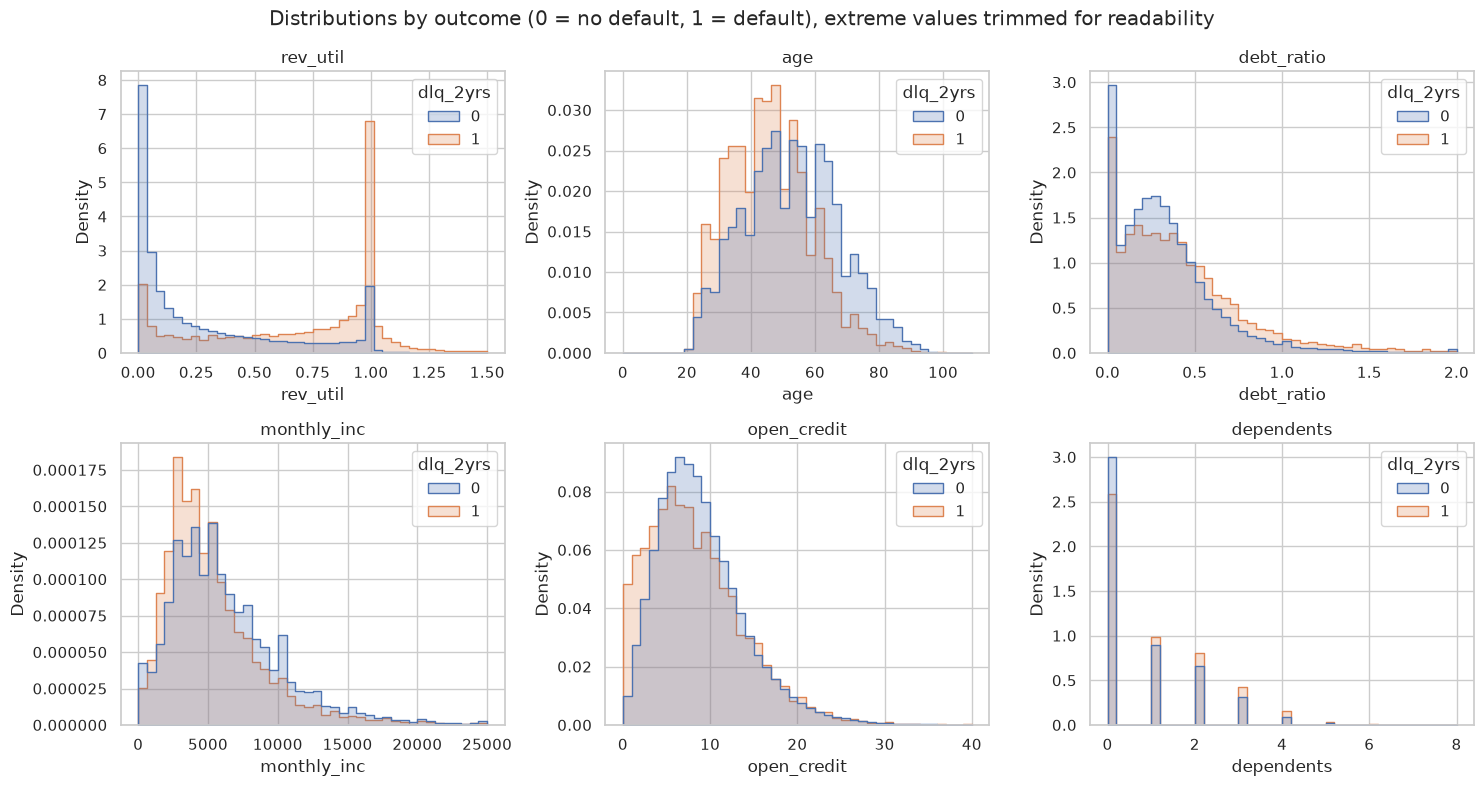

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
plots = [("rev_util", (0, 1.5)), ("age", None), ("debt_ratio", (0, 2)),
         ("monthly_inc", (0, 25_000)), ("open_credit", (0, 40)), ("dependents", (0, 8))]
for ax, (col, lim) in zip(axes.ravel(), plots):
    data = gmsc if lim is None else gmsc[gmsc[col].between(*lim)]
    sns.histplot(data=data, x=col, hue=TARGET, stat="density", common_norm=False, bins=40, ax=ax, element="step")
    ax.set_title(col)
fig.suptitle("Distributions by outcome (0 = no default, 1 = default), extreme values trimmed for readability")
fig.tight_layout()

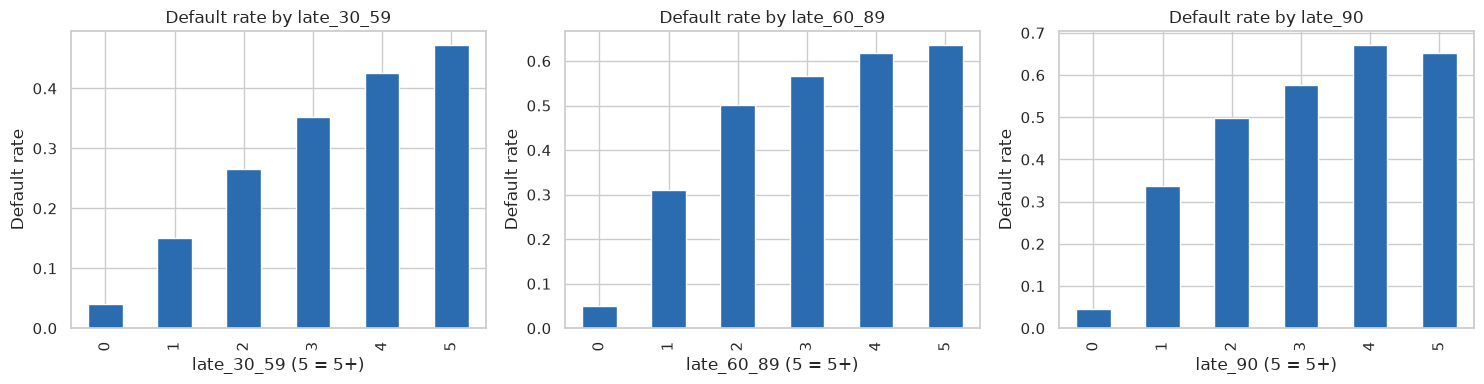

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
clean_late = gmsc[~gmsc[late_cols].isin([96, 98]).any(axis=1)]
for ax, col in zip(axes, late_cols):
    rate = clean_late.groupby(clean_late[col].clip(upper=5))[TARGET].mean()
    rate.plot.bar(ax=ax, color="#2b6cb0")
    ax.set(title=f"Default rate by {col}", xlabel=f"{col} (5 = 5+)", ylabel="Default rate")
fig.tight_layout()

Past payment incidents are by far the strongest signal: a single 90-day late payment multiplies the default rate several times.

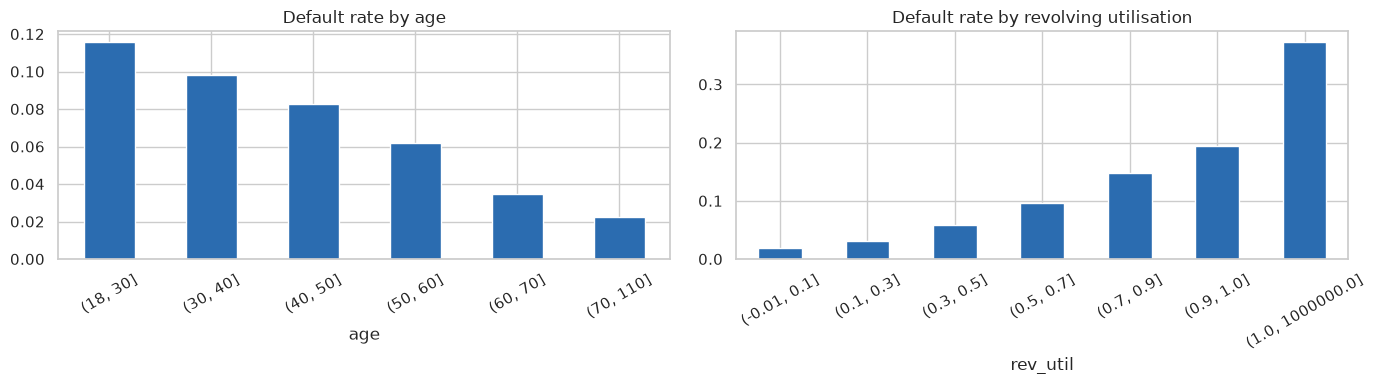

In [9]:
age_rate = gmsc.groupby(pd.cut(gmsc.age, [18, 30, 40, 50, 60, 70, 110]), observed=True)[TARGET].mean()
util_rate = gmsc.groupby(pd.cut(gmsc.rev_util, [-0.01, 0.1, 0.3, 0.5, 0.7, 0.9, 1.0, 1e6]), observed=True)[TARGET].mean()
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
age_rate.plot.bar(ax=ax1, color="#2b6cb0", title="Default rate by age")
util_rate.plot.bar(ax=ax2, color="#2b6cb0", title="Default rate by revolving utilisation")
for ax in (ax1, ax2):
    ax.tick_params(axis="x", rotation=30)
fig.tight_layout()

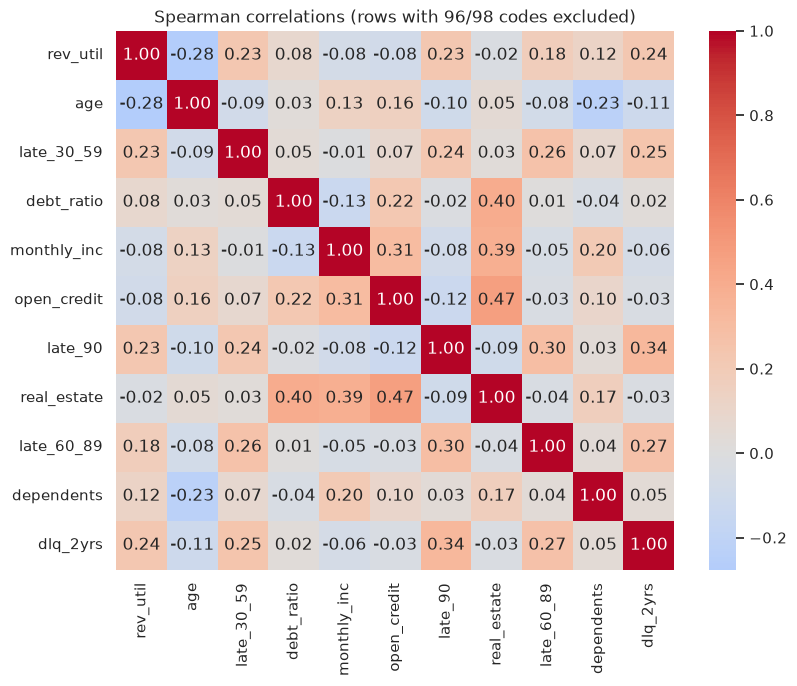

In [10]:
plt.figure(figsize=(9, 7))
sns.heatmap(clean_late[RAW_FEATURES + [TARGET]].corr(method="spearman"), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Spearman correlations (rows with 96/98 codes excluded)");

## 3. Cleaning and feature engineering

`src/features.py` implements the same transformation for training, prediction and the demo app:

* invalid values (96/98 codes, `rev_util > 10`, `age < 18`) are set to missing;
* engineered features: `total_late_payments`, `late_severity_score` (30-59 = 1, 60-89 = 2, 90+ = 3),
  `income_per_dependent`, `monthly_debt` (= `debt_ratio` x income) and an `income_missing` flag.

Missing values are imputed with the median inside each model pipeline (fitted on training data only, so no leakage),
except for gradient boosting which handles them natively. Linear models and the neural network additionally get a
log transform and standard scaling.

In [11]:
build_features(gmsc[RAW_FEATURES]).describe().T[["count", "mean", "50%", "max"]]

,count,mean,50%,max
rev_util,149759.000,0.323,0.154,8.852
age,149999.000,52.296,52.000,109.000
late_30_59,149731.000,0.246,0.000,13.000
debt_ratio,150000.000,353.005,0.367,329664.000
monthly_inc,120269.000,6670.221,5400.000,3008750.000
open_credit,150000.000,8.453,8.000,58.000
late_90,149731.000,0.090,0.000,17.000
real_estate,150000.000,1.018,1.000,54.000
late_60_89,149731.000,0.065,0.000,11.000
dependents,146076.000,0.757,0.000,20.000


## 4. Experiment: does the Kaggle data help?

GMSC is split once into train (80%) and test (20%), stratified. Each model is then trained twice:

* **benchmark**: only the benchmark rows that fall in the training split (~13k rows, balanced);
* **full**: the whole training split (~120k rows, 6.7% defaults);

and both versions are scored on the **same 30,000-row test set**. ROC-AUC does not depend on the class
balance, so the two variants are directly comparable. PR-AUC (average precision) is more demanding on imbalanced
data: a random model would score 0.067.

In [12]:
from src.train import best_f1_threshold, compare, cross_validate_best, split_data

splits, test, bench_ids = split_data()
results, test_proba, fitted = compare(splits, test)

  Logistic Regression  [benchmark] ROC-AUC=0.8541  PR-AUC=0.3721
  Decision Tree        [benchmark] ROC-AUC=0.8457  PR-AUC=0.3439


  Random Forest        [benchmark] ROC-AUC=0.8624  PR-AUC=0.3872


  Gradient Boosting    [benchmark] ROC-AUC=0.8664  PR-AUC=0.4002


  Neural Network       [benchmark] ROC-AUC=0.8361  PR-AUC=0.3488


  Logistic Regression  [full     ] ROC-AUC=0.8599  PR-AUC=0.3790


  Decision Tree        [full     ] ROC-AUC=0.8543  PR-AUC=0.3653


  Random Forest        [full     ] ROC-AUC=0.8663  PR-AUC=0.3983


  Gradient Boosting    [full     ] ROC-AUC=0.8688  PR-AUC=0.4078


  Neural Network       [full     ] ROC-AUC=0.8673  PR-AUC=0.3976


In [13]:
table = results.pivot(index="model", columns="training_data", values=["roc_auc", "pr_auc"])
table[("roc_auc", "gain")] = table[("roc_auc", "full")] - table[("roc_auc", "benchmark")]
table[("pr_auc", "gain")] = table[("pr_auc", "full")] - table[("pr_auc", "benchmark")]
table.sort_values(("roc_auc", "full"), ascending=False).round(4)

roc_auc          pr_auc       roc_auc pr_auc
training_data       benchmark  full benchmark  full    gain   gain
model                                                             
Gradient Boosting       0.866 0.869     0.400 0.408   0.003  0.008
Neural Network          0.836 0.867     0.349 0.398   0.031  0.049
Random Forest           0.862 0.866     0.387 0.398   0.004  0.011
Logistic Regression     0.854 0.860     0.372 0.379   0.006  0.007
Decision Tree           0.846 0.854     0.344 0.365   0.009  0.021

**Findings**

* Adding the Kaggle data improves **every** model, on both ROC-AUC and PR-AUC.
* The gain is small for tree ensembles (+0.002 to +0.004 AUC), which already extract most of the signal from 13k rows,
  and large for the **neural network (+0.03 AUC)**, which needs more data to learn.
* Cleaning the sentinel values and using gradient boosting matters as much as the extra data: even trained on the
  benchmark only, gradient boosting (0.866) beats the original notebook's Random Forest.

![](../reports/figures/data_comparison.png)

## 5. Model selection and decision threshold

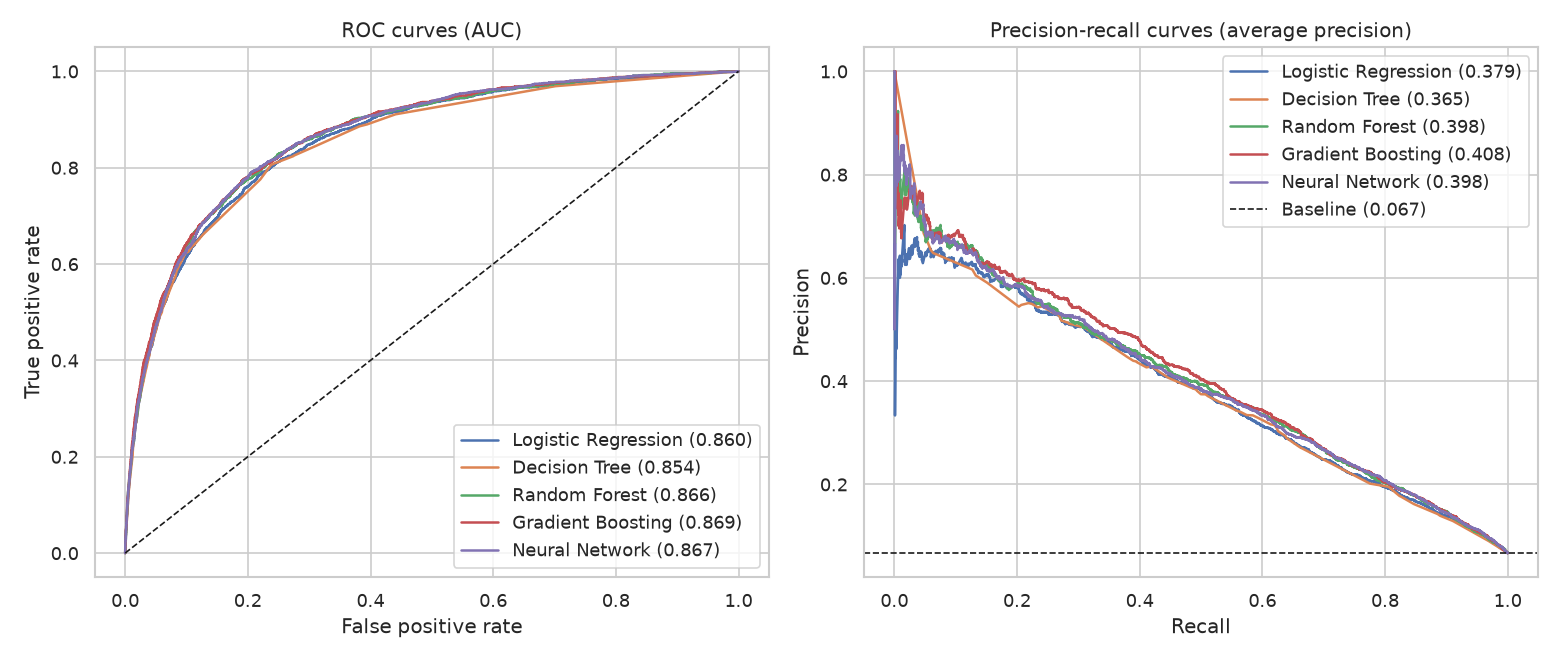

In [14]:
from IPython.display import Image

Image("../reports/figures/roc_pr_curves.png")

Gradient boosting (`HistGradientBoostingClassifier`) has the best ROC-AUC and PR-AUC; it is also the fastest to
train and handles missing values natively, so it is the selected model.

With only 6.7% defaulters, the default 0.5 threshold would flag very few applicants. The threshold is instead
chosen to **maximise F1 on 5-fold out-of-fold predictions of the training set** (the test set is never used for tuning).
In practice a lender would set it from the relative cost of a missed default versus a rejected good customer.

In [15]:
best = "Gradient Boosting"
oof = cross_validate_best(best, splits["full"])
threshold = best_f1_threshold(splits["full"][TARGET], oof)
print(f"Out-of-fold ROC-AUC: {roc_auc_score(splits['full'][TARGET], oof):.4f}")
print(f"Chosen threshold: {threshold:.3f}\n")
y_pred = (test_proba[best] >= threshold).astype(int)
print(classification_report(test[TARGET], y_pred, target_names=["No default", "Default"]))

Out-of-fold ROC-AUC: 0.8645
Chosen threshold: 0.219

              precision    recall  f1-score   support

  No default       0.96      0.95      0.96     27995
     Default       0.40      0.50      0.45      2005

    accuracy                           0.92     30000
   macro avg       0.68      0.72      0.70     30000
weighted avg       0.93      0.92      0.92     30000



In [16]:
in_bench = test.index.isin(bench_ids)
print(f"ROC-AUC on the {in_bench.sum():,} benchmark rows of the test set: "
      f"{roc_auc_score(test.loc[in_bench, TARGET], test_proba[best][in_bench]):.4f}")

ROC-AUC on the 3,303 benchmark rows of the test set: 0.8639


For comparison with the original balanced setup (Random Forest, ROC-AUC 0.855 on a benchmark test split),
the new model reaches about 0.864 on the benchmark rows of the test set.

At the chosen threshold the model catches about half of the defaulters while flagging ~8% of applicants.

![](../reports/figures/confusion_matrix.png)

### What drives the predictions?

Permutation importance measures how much the test ROC-AUC drops when a raw input is shuffled. Revolving
utilisation and the payment-history counters dominate, which matches the EDA.

![](../reports/figures/feature_importance.png)

## 6. Neural network and TensorFlow Lite export

A small Keras MLP (64 -> 32 -> 1, dropout 0.2, early stopping on validation AUC) is trained on the same features,
log-transformed and standardised. It is exported as `.keras` and converted to `.tflite` for lightweight
deployment (mobile, edge, or tools such as Power BI via Python).

In [17]:
from src.models import fit_nn, predict_nn

pre, nn, history = fit_nn(splits["full"][RAW_FEATURES], splits["full"][TARGET])
nn.summary()
hist = pd.DataFrame(history.history)
ax = hist[["auc", "val_auc"]].plot(figsize=(8, 4), title="Neural network training (AUC)")
ax.set_xlabel("epoch");
print(f"Test ROC-AUC: {roc_auc_score(test[TARGET], predict_nn(pre, nn, test[RAW_FEATURES])):.4f}")

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 64)             │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,413 (36.77 KB)

 Trainable params: 3,137 (12.25 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 6,276 (24.52 KB)

Test ROC-AUC: 0.8673


In [18]:
import warnings

import tensorflow as tf

warnings.filterwarnings("ignore", message=".*tf.lite.Interpreter is deprecated.*")
tflite_bytes = tf.lite.TFLiteConverter.from_keras_model(nn).convert()  # temporary SavedModel logs may appear here
interpreter = tf.lite.Interpreter(model_content=tflite_bytes)
interpreter.allocate_tensors()
inp, out = interpreter.get_input_details()[0], interpreter.get_output_details()[0]

X_sample = pre.transform(test[RAW_FEATURES].head(500)).astype("float32")
tflite_pred = []
for row in X_sample:
    interpreter.set_tensor(inp["index"], row[None])
    interpreter.invoke()
    tflite_pred.append(interpreter.get_tensor(out["index"])[0, 0])
keras_pred = nn.predict(X_sample, verbose=0).ravel()
print(f"TFLite model size: {len(tflite_bytes) / 1024:.1f} KB")
print(f"Max |Keras - TFLite| difference: {np.abs(keras_pred - np.array(tflite_pred)).max():.2e}")

INFO:tensorflow:Assets written to: /tmp/tmp4tra3omv/assets


INFO:tensorflow:Assets written to: /tmp/tmp4tra3omv/assets


Saved artifact at '/tmp/tmp4tra3omv'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 15), dtype=tf.float32, name='keras_tensor_12')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  135576858336080: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135576858343184: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135576858339728: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135576858344528: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135576858342224: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135576858342800: TensorSpec(shape=(), dtype=tf.resource, name=None)


INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


TFLite model size: 14.4 KB
Max |Keras - TFLite| difference: 1.19e-07


## 7. Conclusions

* **Selected model:** gradient boosting, test ROC-AUC ≈ 0.869 and PR-AUC ≈ 0.41 on 30,000 unseen borrowers.
* **More data helps:** the Kaggle data improves every model; the neural network benefits most (+0.03 AUC) and
  becomes competitive with the tree ensembles.
* **Data quality matters:** handling the 96/98 codes and extreme ratios is as important as the choice of model.
* **Key risk drivers:** revolving utilisation and past late payments.

**Limitations**

* The data is anonymised US consumer credit data from ~2011; it may not transfer to other markets or periods.
* Probabilities are not formally calibrated and the threshold maximises F1, not a business cost function.
* No fairness analysis was done (age is used as a feature, which may be restricted in real lending).

To reproduce the saved models and figures: `python -m src.train`. To try the model: `streamlit run app/streamlit_app.py`.